# Hierarchical clustering

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [14]:
plt.style.use("my_style.mplstyle")

In [2]:
models_dsct=['GNO', 'UNO', 'PINK', 'BROWN', 'VIOLET', # noises (R)
        'AR1_GNO', 'STAR_GNO', #    ARMA (R)
        'ARNOLD', 'CHIRIKOV', # Conservative chaotic maps (R)
        'HENR_diverse', 'HENR_same', 'QUADRATIC_RSUM', # Sum of frwd and bckwd realisations of chaotic maps (R)
        'AR1_UNO', 'ARMA11_UNO', 'AR3_Gamma', 'N_AR2', 'SETAR1_GNO', 'SETAR2_GNO',
        'HEN', 'HEN_SUM', 'LOGISTIC4', 'LOGISTIC38284', 'QUADRATIC', # Chaotic maps (I)
        'MODA', 'LLOG', # Other deterministic (I)
        'SINE_STOCH' # Other stochastic (I)
        ]



models_cnt = ['BRW_cont','OU', 'Oscillator', 
              'LORENZ_SUM', 'ROSSLER_SUM', 
              'MACKEYGLASS17', 'VDP', 
              'LORENZ_STOCH_SUM',
                'VDP_STOCH']


models = models_dsct + models_cnt
print('Models:', models)

model_keywords={ # discrete
                'GNO': 'reversible', 'UNO': 'reversible', 'PINK': 'reversible', 'BROWN': 'reversible', 'VIOLET': 'reversible',
                'AR1_GNO': 'reversible', 'STAR_GNO': 'reversible',
                'ARNOLD': 'reversible', 'CHIRIKOV': 'reversible',
                'HENR_diverse': 'reversible', 'HENR_same': 'reversible', 'QUADRATIC_RSUM': 'reversible',
                'AR1_UNO': 'irreversible', 'ARMA11_UNO': 'irreversible', 'AR3_Gamma': 'irreversible', 'N_AR2': 'irreversible', 'SETAR1_GNO': 'irreversible', 'SETAR2_GNO': 'irreversible', 
                'HEN': 'irreversible', 'HEN_SUM': 'irreversible', 'LOGISTIC4': 'irreversible', 'LOGISTIC38284': 'irreversible','QUADRATIC': 'irreversible',
                'MODA': 'irreversible', 'LLOG': 'irreversible',
                'SINE_STOCH': 'irreversible',
                # continuous
                'BRW_cont': 'reversible', 'OU': 'reversible', 'Oscillator': 'reversible',
                'LORENZ_SUM': 'irreversible', 'ROSSLER_SUM': 'irreversible',
                'MACKEYGLASS17': 'irreversible', 'VDP': 'irreversible',
                'LORENZ_STOCH_SUM': 'irreversible',
                'VDP_STOCH': 'irreversible'
        }


Models: ['GNO', 'UNO', 'PINK', 'BROWN', 'VIOLET', 'AR1_GNO', 'STAR_GNO', 'ARNOLD', 'CHIRIKOV', 'HENR_diverse', 'HENR_same', 'QUADRATIC_RSUM', 'AR1_UNO', 'ARMA11_UNO', 'AR3_Gamma', 'N_AR2', 'SETAR1_GNO', 'SETAR2_GNO', 'HEN', 'HEN_SUM', 'LOGISTIC4', 'LOGISTIC38284', 'QUADRATIC', 'MODA', 'LLOG', 'SINE_STOCH', 'BRW_cont', 'OU', 'Oscillator', 'LORENZ_SUM', 'ROSSLER_SUM', 'MACKEYGLASS17', 'VDP', 'LORENZ_STOCH_SUM', 'VDP_STOCH']


In [ ]:
cwd = os.getcwd()

dir_hctsa= cwd+'/data-analysis/'
dir_accuracy= cwd+'/data-analysis/accuracy/'
dir_zero=cwd+'/data-zero/'
dir_figures=cwd+'/data-analysis/figures/'

In [5]:
# Load good performing features
df_ops_good = pd.read_csv(dir_accuracy+'df_accuracy_good_1NN.csv')

df_good_hctsa = pd.read_csv(dir_accuracy+'df_good_hctsa_1NN.csv')
df_good_hctsa.set_index('Model', inplace=True)

In [ ]:
# Load zero features
df_ops_zero=pd.read_csv(dir_zero+'df_ops_zero.csv')

In [7]:
# Check what good features are among the zero ones
common_values = pd.merge(df_ops_good, df_ops_zero, left_on='Operation', right_on='Name', how='inner')

# Display the common values
print(common_values)

Empty DataFrame
Columns: [Operation, Accuracy, Name, Value]
Index: []


In [8]:
# hierarchical clustering
df_good_hctsa=df_good_hctsa.iloc[:,1:]

In [9]:
# Compute correlation matrix for selected hctsa data
corr_mtrx=df_good_hctsa.corr(method='spearman') # to do with spearman

# Check for NaN values
if corr_mtrx.isnull().values.any():
    raise ValueError("Error: The correlation matrix contains NaN values.")

# If value outside [-1,1] (numerical errors) set to -1 or 1
corr_mtrx[corr_mtrx>1]=1.0
corr_mtrx[corr_mtrx<-1]=-1.0

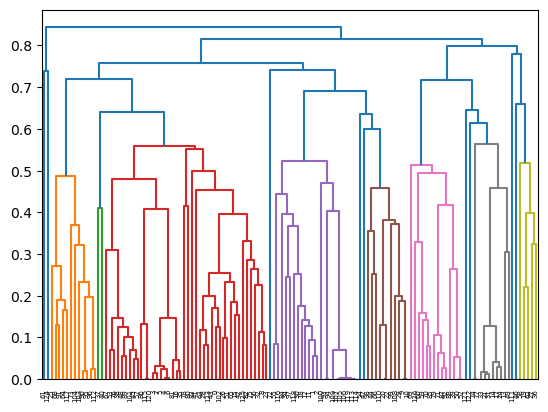

In [10]:
# Compute distance matrix from correlation
dist_mtrx=1-abs(corr_mtrx)
# Convert to squareform and compute linkage
Z = linkage(squareform(dist_mtrx), 'average', metric='euclidean')
dd=dendrogram(Z, labels=None, orientation='top', 
           leaf_rotation=90,
            show_leaf_counts=True)

In [11]:
# Sorted correlation matrix (from dendrogram leaves)

corr_mtrx_sorted=corr_mtrx.iloc[dd['leaves'],dd['leaves']]
dist_mtrx_sorted=1-abs(corr_mtrx_sorted)

Text(0.5, 1.0, 'Sorted Distance Matrix Heatmap')

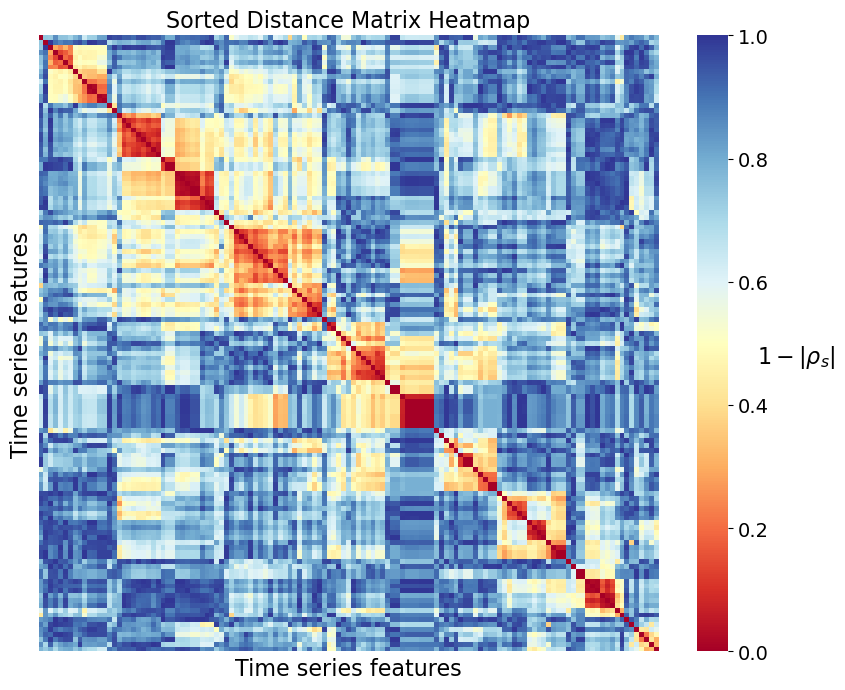

In [12]:
plt.figure(figsize=(10,8))
hm=sns.heatmap(dist_mtrx_sorted,
            cmap='RdYlBu', annot=False, #'RdYlBu'
            xticklabels=False, yticklabels=False,
            vmin=0, vmax=1
            )
colorbar = hm.collections[0].colorbar
colorbar.set_label(r'$1-|\rho_s|$', rotation=0, labelpad=20, fontsize=16) 
colorbar.ax.tick_params(labelsize=14)

plt.xlabel('Time series features', fontsize=16)
plt.ylabel('Time series features', fontsize=16)
plt.title('Sorted Distance Matrix Heatmap', fontsize=16)

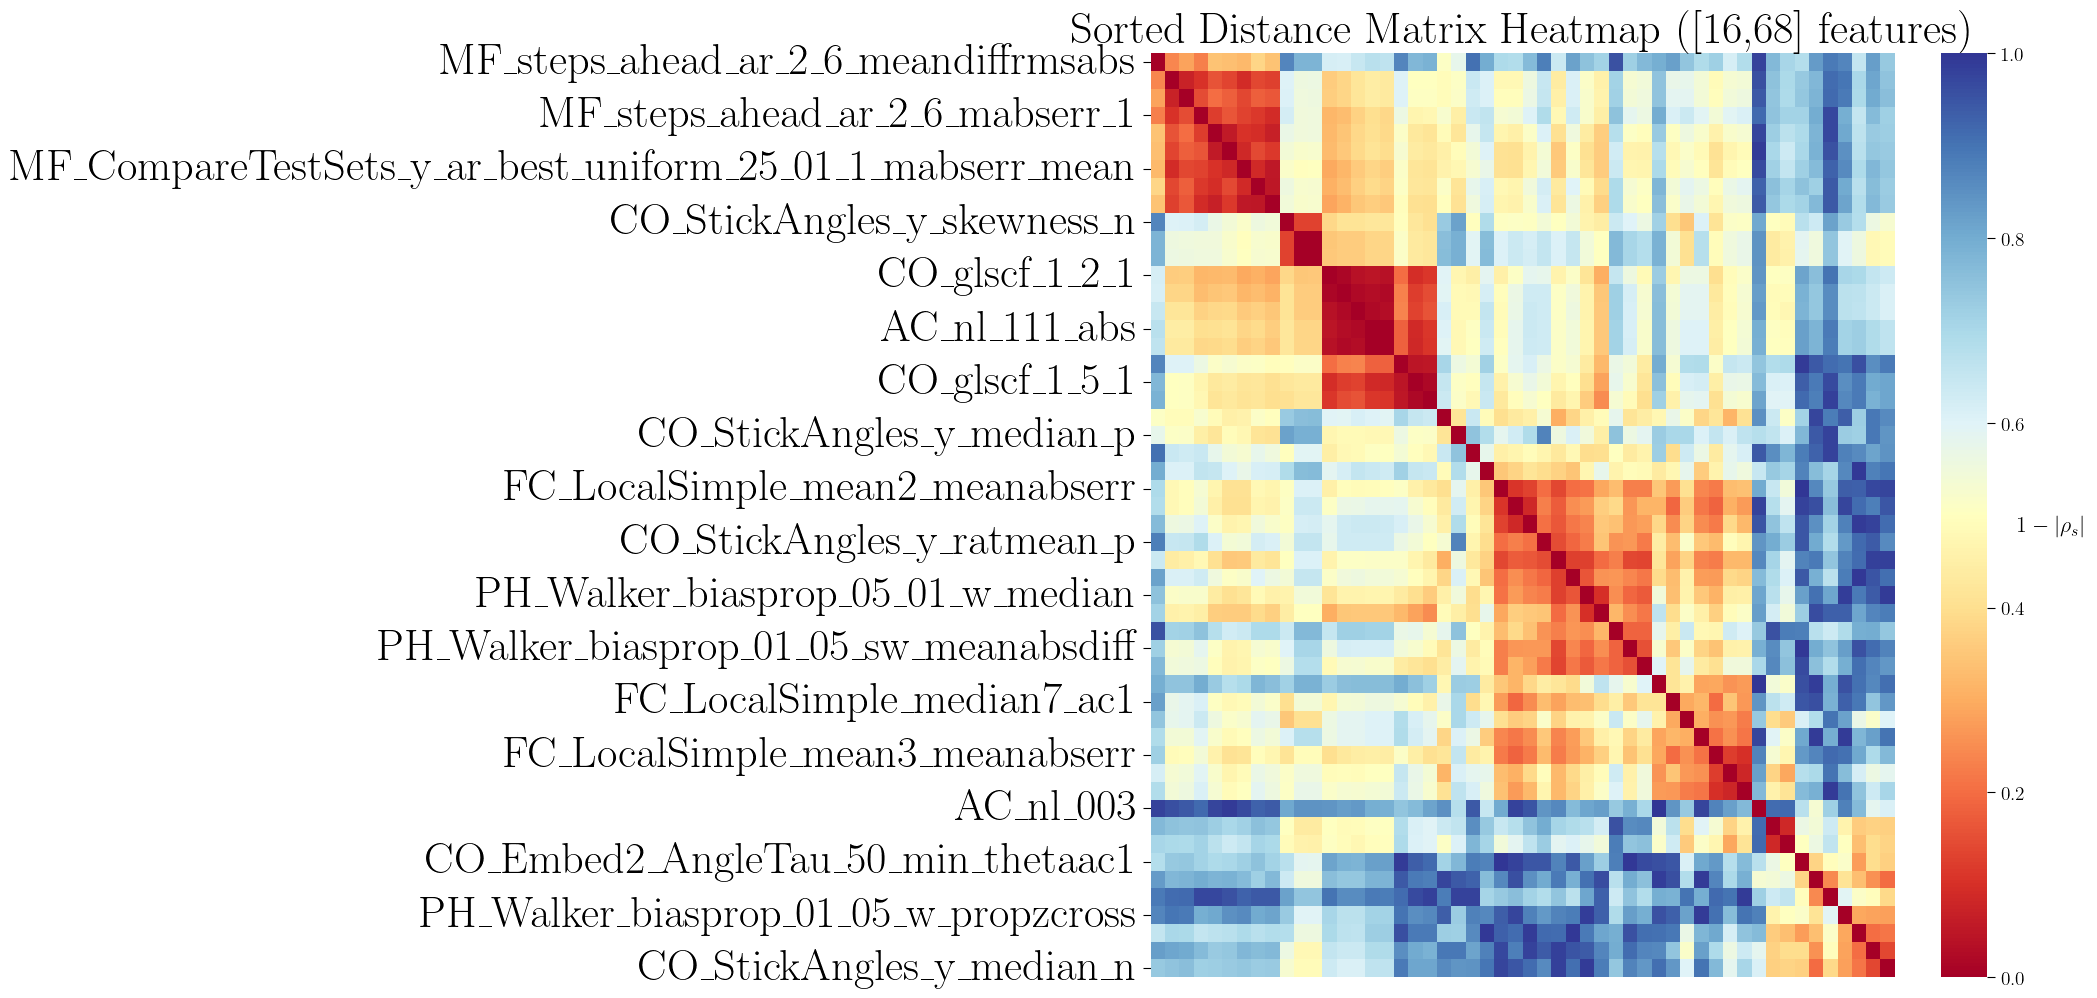

In [18]:
# Plot a portion of the sorted distance matrix
# good correlation cluster [51,84] ci sarebbe anche intorno a 100
# correlation cluster [120,160]

plt.figure(figsize=(12,12))
n0=16
n1=68



hm_small=sns.heatmap(dist_mtrx_sorted.iloc[n0:n1,n0:n1], 
                     cmap='RdYlBu', xticklabels=False,
                     #linewidths=0.5, linecolor='white',
                     annot=False, vmin=0, vmax=1)
plt.title(f'Sorted Distance Matrix Heatmap ([{n0},{n1}] features)')
colorbar = hm_small.collections[0].colorbar
colorbar.set_label(r'$1-|\rho_s|$', rotation=0, labelpad=20, fontsize=16) 
colorbar.ax.tick_params(labelsize=14)

# SAVE
plt.savefig(dir_figures+'heatmap.png', dpi=300, bbox_inches='tight')